In [1]:

import sqlite3
import pandas as pd
import os
import shutil
import subprocess
import tarfile

BUCKET_ID = "project-0c281f60-a9e8-4b55-949-chembl-data"
BUCKET_ROOT = f"gs://{BUCKET_ID}"
FILENAME = "chembl_36_sqlite.tar.gz"
LOCAL_WORK_DIR = "chembl_work"
PARQUET_DIR = os.path.join(LOCAL_WORK_DIR, "parquet_bronze")

if not os.path.exists(LOCAL_WORK_DIR):
    os.makedirs(LOCAL_WORK_DIR)
    print(f"Pobieranie {FILENAME}...")
    subprocess.check_call(["gsutil", "cp", f"{BUCKET_ROOT}/raw/{FILENAME}", os.path.join(LOCAL_WORK_DIR, FILENAME)])
    
    print("Rozpakowywanie")
    with tarfile.open(os.path.join(LOCAL_WORK_DIR, FILENAME), "r:gz") as tar:
        tar.extractall(path=LOCAL_WORK_DIR)

db_path = None
for root, dirs, files in os.walk(LOCAL_WORK_DIR):
    for file in files:
        if file.endswith(".db"):
            db_path = os.path.join(root, file)
            print(f"Baza SQLite: {db_path}")
            break

def sql_to_parquet_pandas(table_name, sql_query):
    print(f"\nPrzetwarzanie tabeli: {table_name}...")
    conn = sqlite3.connect(db_path)
    os.makedirs(PARQUET_DIR, exist_ok=True)
    output_file = os.path.join(PARQUET_DIR, f"{table_name}.parquet")
    
    if os.path.exists(output_file):
        print(f"   Plik {output_file} juz istnieje. Pomijam.")
        return

    chunks = []
    total_rows = 0
    for chunk in pd.read_sql_query(sql_query, conn, chunksize=500000):
        for col in chunk.select_dtypes(include=['float64']).columns:
            chunk[col] = chunk[col].astype('float32')
        for col in chunk.select_dtypes(include=['int64']).columns:
            chunk[col] = chunk[col].astype('int32')
            
        chunks.append(chunk)
        total_rows += len(chunk)
        print(f"   Wczytano chunk: {len(chunk)} wierszy...", end="\r")
    
    print(f"\n   Sklejanie {total_rows} wierszy i zapis do Parquet...")
    df_full = pd.concat(chunks, ignore_index=True)
    df_full.to_parquet(output_file, engine='pyarrow', index=False)
    
    del df_full
    del chunks
    conn.close()
    print(f"Gotowe: {output_file}")

sql_to_parquet_pandas("activities", "SELECT * FROM activities")
sql_to_parquet_pandas("assays", "SELECT * FROM assays")
sql_to_parquet_pandas("targets", "SELECT * FROM target_dictionary")
sql_to_parquet_pandas("molecules", """
    SELECT md.*, cs.canonical_smiles 
    FROM molecule_dictionary md
    LEFT JOIN compound_structures cs ON md.molregno = cs.molregno
""")


Baza SQLite: chembl_work/chembl_36/chembl_36_sqlite/chembl_36.db

Przetwarzanie tabeli: activities...
   Plik chembl_work/parquet_bronze/activities.parquet juz istnieje. Pomijam.

Przetwarzanie tabeli: assays...
   Plik chembl_work/parquet_bronze/assays.parquet juz istnieje. Pomijam.

Przetwarzanie tabeli: targets...
   Plik chembl_work/parquet_bronze/targets.parquet juz istnieje. Pomijam.

Przetwarzanie tabeli: molecules...
   Plik chembl_work/parquet_bronze/molecules.parquet juz istnieje. Pomijam.



ANALIZA TABELI: MOLECULES
Wymiary: 2,878,135 wierszy, 29 kolumn

Probka danych (Top 3):


,molregno,pref_name,chembl_id,max_phase,therapeutic_flag,dosed_ingredient,structure_type,molecule_type,first_approval,oral,parenteral,topical,black_box_warning,natural_product,first_in_class,chirality,prodrug,inorganic_flag,usan_year,availability_type,usan_stem,polymer_flag,usan_substem,usan_stem_definition,withdrawn_flag,chemical_probe,orphan,veterinary,canonical_smiles
0,1,None,CHEMBL6329,NaN,0,0,MOL,Small molecule,NaN,0,0,0,0,0,-1,-1,-1,-1,NaN,-1.0,None,0,None,None,0,0,-1,-1,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl
1,2,None,CHEMBL6328,NaN,0,0,MOL,Small molecule,NaN,0,0,0,0,0,-1,-1,-1,-1,NaN,-1.0,None,0,None,None,0,0,-1,-1,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1
2,3,None,CHEMBL265667,NaN,0,0,MOL,Small molecule,NaN,0,0,0,0,0,-1,-1,-1,-1,NaN,-1.0,None,0,None,None,0,0,-1,-1,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1



Typy danych:
int32      17
object      8
float32     4
Name: count, dtype: int64

Analiza NULLi (Brakujace wartosci):
                       % Brakow Decyzja
first_approval        99.868352    DROP
usan_year             99.707727    DROP
usan_stem             99.634138    DROP
usan_substem          99.634138    DROP
usan_stem_definition  99.634138    DROP
max_phase             99.329079    DROP
pref_name             98.293548    DROP
molecule_type         18.344345  IMPUTE
canonical_smiles       0.810247  IMPUTE
availability_type      0.527216  IMPUTE


/var/tmp/ipykernel_10753/2371794835.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index[:20], y=missing.values[:20], palette="Reds_r")


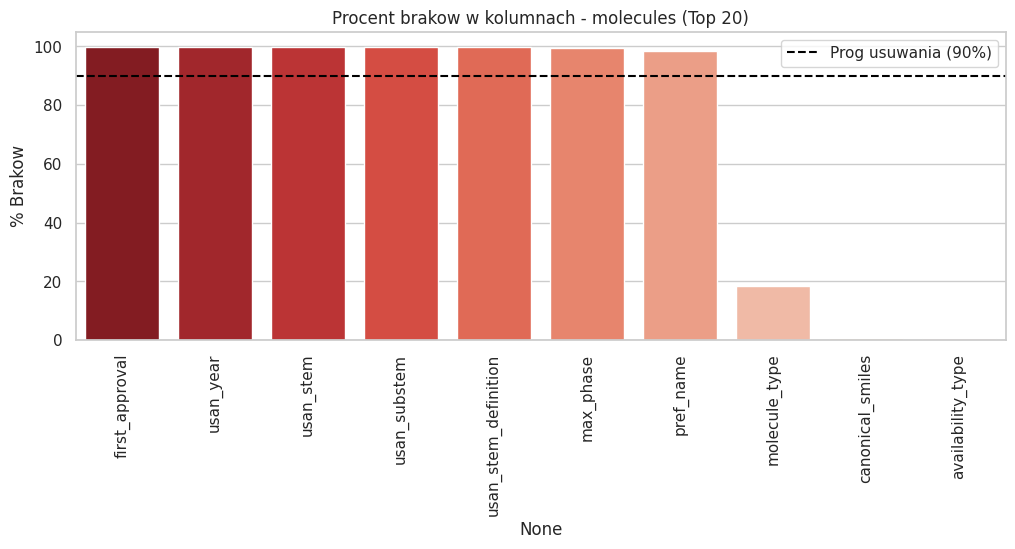


Rozklad kolumn kategorycznych:

Kolumna: structure_type
structure_type
MOL     2832750
BOTH      22065
NONE      21464
Name: count, dtype: int64

Kolumna: molecule_type
molecule_type
Small molecule    1920603
Unknown            404710
Protein             22870
Name: count, dtype: int64

Statystyki kolumn numerycznych:


,count,mean,std,min,25%,50%,75%,max
molregno,2878135.0,1.682164e+06,976284.414019,1.0,807827.5,1750997.0,2541848.0,3286600.0
max_phase,19310.0,2.038736e+00,1.482170,-1.0,2.0,2.0,3.0,4.0
therapeutic_flag,2878135.0,1.350875e-03,0.036729,0.0,0.0,0.0,0.0,1.0
dosed_ingredient,2878135.0,1.058324e-03,0.032515,0.0,0.0,0.0,0.0,1.0
first_approval,3789.0,1.993132e+03,20.804571,1934.0,1982.0,1995.0,2012.0,2024.0
oral,2878135.0,6.841236e-04,0.026147,0.0,0.0,0.0,0.0,1.0
parenteral,2878135.0,5.458396e-04,0.023357,0.0,0.0,0.0,0.0,1.0
topical,2878135.0,2.088158e-04,0.014449,0.0,0.0,0.0,0.0,1.0
black_box_warning,2878135.0,3.252106e-04,0.018031,0.0,0.0,0.0,0.0,1.0
natural_product,2878135.0,3.423953e-02,0.181844,0.0,0.0,0.0,0.0,1.0



Korelacja cech (Heatmapa):


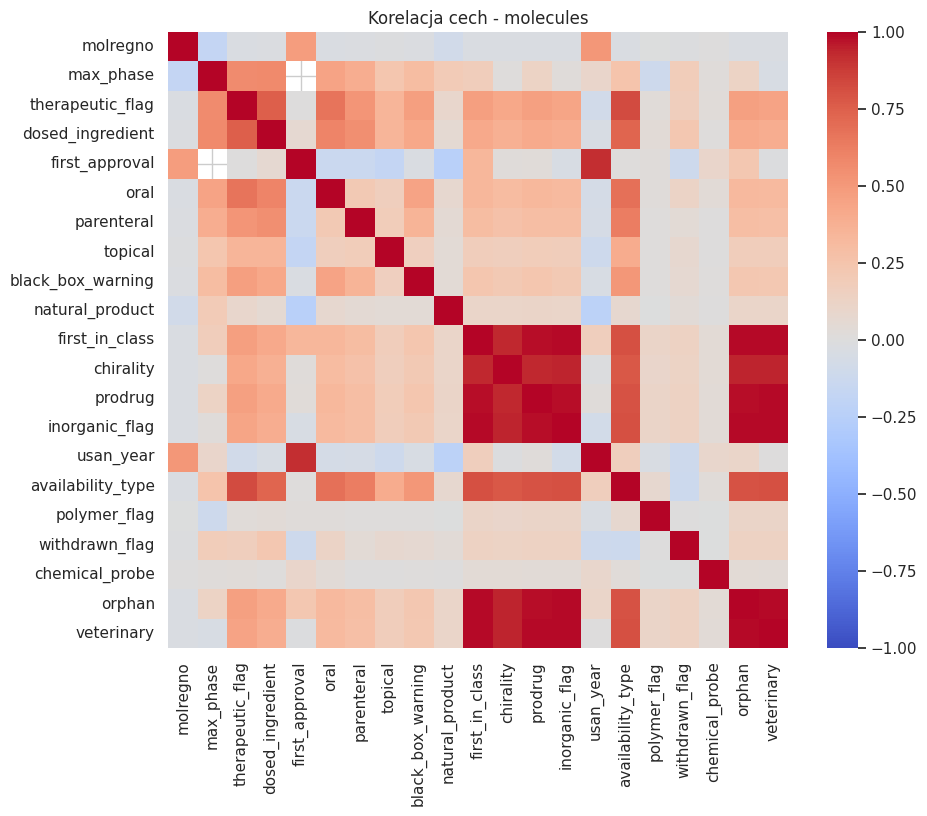

Silnie skorelowane pary (>0.95):
   - prodrug <-> first_in_class: 0.9806
   - inorganic_flag <-> first_in_class: 0.9863
   - inorganic_flag <-> prodrug: 0.9831
   - orphan <-> first_in_class: 0.9906
   - orphan <-> prodrug: 0.9842
   - orphan <-> inorganic_flag: 0.9901
   - veterinary <-> first_in_class: 0.9882
   - veterinary <-> prodrug: 0.9851
   - veterinary <-> inorganic_flag: 0.9916
   - veterinary <-> orphan: 0.9920

--------------------------------------------------------------------------------


ANALIZA TABELI: ACTIVITIES
Wymiary: 24,267,312 wierszy, 28 kolumn

Probka danych (Top 3):


,activity_id,assay_id,doc_id,record_id,molregno,standard_relation,standard_value,standard_units,standard_flag,standard_type,activity_comment,data_validity_comment,potential_duplicate,pchembl_value,bao_endpoint,uo_units,qudt_units,toid,upper_value,standard_upper_value,src_id,type,relation,value,units,text_value,standard_text_value,action_type
0,31863,54505,6424,206172,180094,>,100000.0,nM,1,IC50,None,None,0,NaN,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,NaN,NaN,None,1,IC50,>,100.0,uM,None,None,None
1,31864,83907,6432,208970,182268,=,2500.0,nM,1,IC50,None,None,0,5.6,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,NaN,NaN,None,1,IC50,=,2.5,uM,None,None,None
2,31865,88152,6432,208970,182268,>,50000.0,nM,1,IC50,None,None,0,NaN,BAO_0000190,UO_0000065,http://www.openphacts.org/units/Nanomolar,NaN,NaN,None,1,IC50,>,50.0,uM,None,None,None



Typy danych:
object     15
int32       8
float32     5
Name: count, dtype: int64

Analiza NULLi (Brakujace wartosci):
                         % Brakow    Decyzja
standard_upper_value   100.000000       DROP
upper_value             99.770881       DROP
standard_text_value     98.673166       DROP
text_value              98.673166       DROP
data_validity_comment   98.560553       DROP
action_type             97.878706       DROP
toid                    96.126106       DROP
pchembl_value           79.821453  SPRAWDZIC
activity_comment        46.847842     IMPUTE
standard_relation       30.518287     IMPUTE
relation                30.505760     IMPUTE
units                   22.921162     IMPUTE
qudt_units              19.927432     IMPUTE
uo_units                19.271207     IMPUTE
standard_units          13.824016     IMPUTE


/var/tmp/ipykernel_10753/2371794835.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index[:20], y=missing.values[:20], palette="Reds_r")


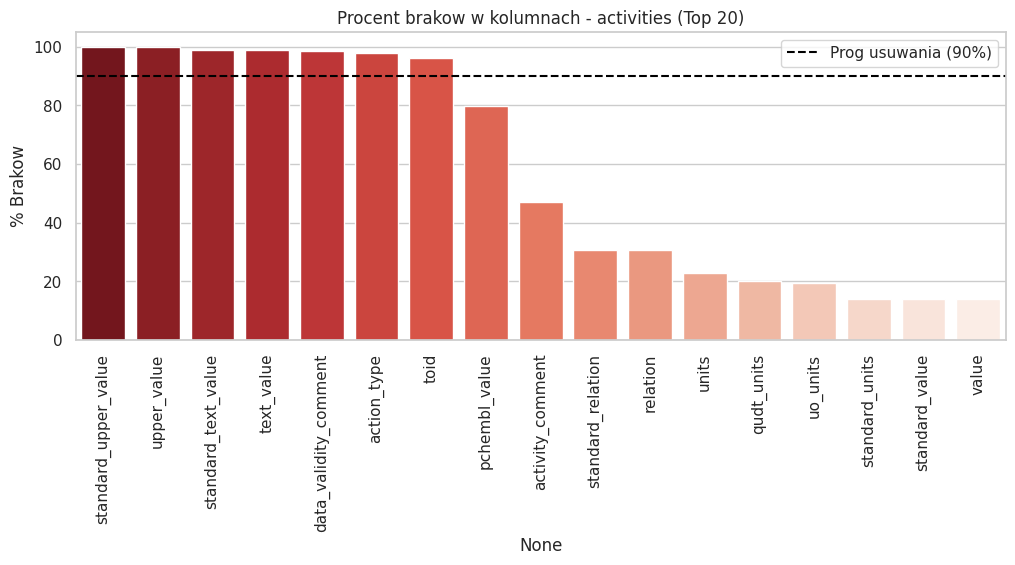


Rozklad kolumn kategorycznych:

Kolumna: standard_relation
standard_relation
=    14873384
>     1576805
<      341490
Name: count, dtype: int64

Kolumna: data_validity_comment
data_validity_comment
Outside typical range            341814
Potential transcription error      4326
Potential missing data             2513
Name: count, dtype: int64

Kolumna: bao_endpoint
bao_endpoint
BAO_0000179    5569721
BAO_0000186    4773860
BAO_0000190    3552865
Name: count, dtype: int64

Kolumna: uo_units
uo_units
UO_0000065    12587576
UO_0000187     5200597
UO_0000274     1030030
Name: count, dtype: int64

Kolumna: qudt_units
qudt_units
http://www.openphacts.org/units/Nanomolar                 12587576
http://qudt.org/vocab/unit#Percent                         5200597
http://www.openphacts.org/units/MicrogramPerMilliliter     1030030
Name: count, dtype: int64

Statystyki kolumn numerycznych:


/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/conda/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
activity_id,24267312.0,1.423299e+07,8.643832e+06,3.186300e+04,6759732.75,13334967.50,21699465.25,2.905464e+07
assay_id,24267312.0,1.342253e+06,7.478636e+05,1.000000e+00,752407.00,954801.00,1998122.00,2.596842e+06
doc_id,24267312.0,7.989273e+04,3.644238e+04,1.000000e+00,51887.00,67108.00,115307.00,1.359250e+05
record_id,24267312.0,2.259934e+06,1.280299e+06,1.000000e+00,1194712.00,1809371.00,3372430.00,4.647906e+06
molregno,24267312.0,1.441649e+06,9.279104e+05,1.000000e+00,735624.00,1308418.00,2154241.25,3.283448e+06
standard_value,20921972.0,1.969253e+22,inf,-7.520000e+09,10.00,460.00,19000.00,4.000000e+29
standard_flag,24267312.0,6.465521e-01,4.780403e-01,0.000000e+00,0.00,1.00,1.00,1.000000e+00
potential_duplicate,24267312.0,1.463413e-02,1.200832e-01,0.000000e+00,0.00,0.00,0.00,1.000000e+00
pchembl_value,4896791.0,6.108430e+00,1.423743e+00,8.500000e-01,4.90,5.82,7.14,1.492000e+01
toid,940090.0,1.895400e+04,1.151705e+04,4.781000e+03,10134.00,13563.00,26331.00,4.305600e+04



Korelacja cech (Heatmapa):


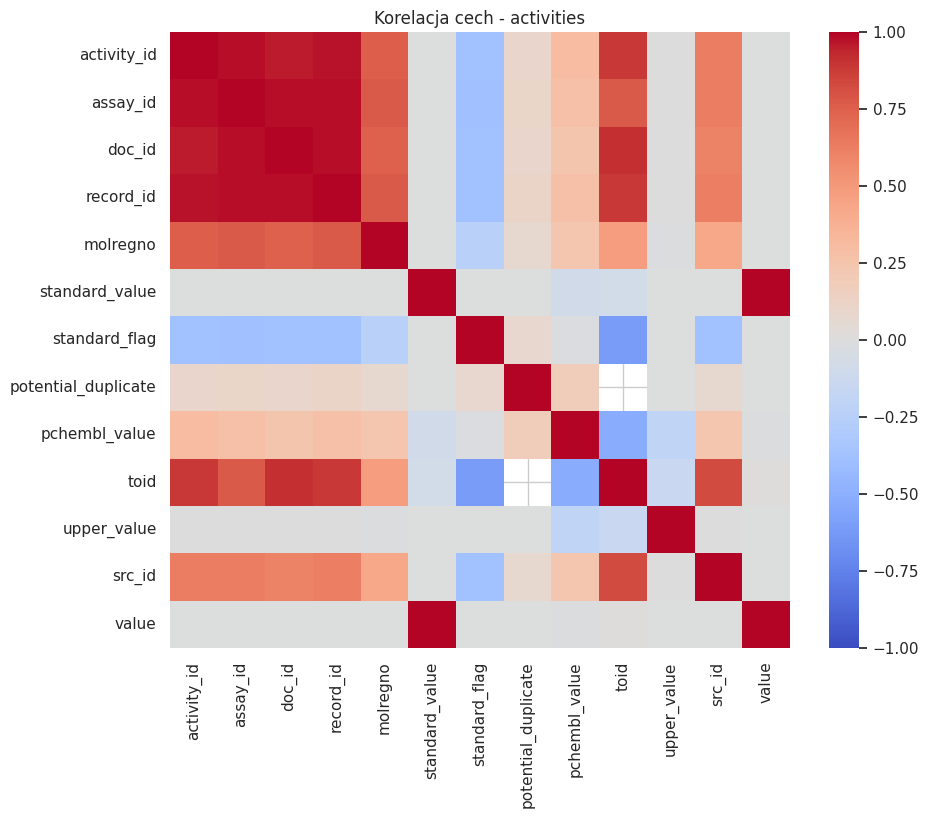

Silnie skorelowane pary (>0.95):
   - assay_id <-> activity_id: 0.9802
   - doc_id <-> activity_id: 0.9583
   - doc_id <-> assay_id: 0.9770
   - record_id <-> activity_id: 0.9712
   - record_id <-> assay_id: 0.9789
   - record_id <-> doc_id: 0.9838
   - value <-> standard_value: 0.9997

--------------------------------------------------------------------------------



In [2]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set(style="whitegrid")

PARQUET_DIR = os.path.join("chembl_work", "parquet_bronze")

def analyze_single_table(table_name):
    path = os.path.join(PARQUET_DIR, f"{table_name}.parquet")
    if not os.path.exists(path):
        print(f"Nie znaleziono pliku: {path}")
        return

    print(f"\n{'='*80}")
    print(f"ANALIZA TABELI: {table_name.upper()}")
    print(f"{'='*80}")
    
    df = pd.read_parquet(path)
    
    print(f"Wymiary: {df.shape[0]:,} wierszy, {df.shape[1]} kolumn")
    print("\nProbka danych (Top 3):")
    display(df.head(3))
    
    print("\nTypy danych:")
    print(df.dtypes.value_counts())
    
    print("\nAnaliza NULLi (Brakujace wartosci):")
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if not missing.empty:
        missing_df = pd.DataFrame({'% Brakow': missing})
        missing_df['Decyzja'] = np.where(missing_df['% Brakow'] > 90, 'DROP', 
                                np.where(missing_df['% Brakow'] > 50, 'SPRAWDZIC', 'IMPUTE'))
        print(missing_df.head(15))
        
        plt.figure(figsize=(12, 4))
        sns.barplot(x=missing.index[:20], y=missing.values[:20], palette="Reds_r")
        plt.xticks(rotation=90)
        plt.title(f"Procent brakow w kolumnach - {table_name} (Top 20)")
        plt.ylabel("% Brakow")
        plt.axhline(90, color='black', linestyle='--', label='Prog usuwania (90%)')
        plt.legend()
        plt.show()
    else:
        print("Ta tabela jest kompletna (brak nulli)!")

    print("\nRozklad kolumn kategorycznych:")
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    important_cats = [c for c in cat_cols if df[c].nunique() < 100]
    
    for col in list(important_cats)[:5]: 
        print(f"\nKolumna: {col}")
        print(df[col].value_counts().head(3))
        
    print("\nStatystyki kolumn numerycznych:")
    num_cols = df.select_dtypes(include=['number']).columns
    if len(num_cols) > 0:
        display(df[num_cols].describe().T.head(10))
        
        print("\nKorelacja cech (Heatmapa):")
        corr = df[num_cols].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title(f"Korelacja cech - {table_name}")
        plt.show()
        
        print("Silnie skorelowane pary (>0.95):")
        for i in range(len(corr.columns)):
            for j in range(i):
                if abs(corr.iloc[i, j]) > 0.95:
                    print(f"   - {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.4f}")

    print("\n" + "-"*80 + "\n")
    return df

# ==========================================
# URUCHOMIENIE ANALIZY DLA KAZDEJ TABELI
# ==========================================

df_mol = analyze_single_table("molecules")
df_act = analyze_single_table("activities")


In [3]:

import pandas as pd
import numpy as np
import os

PARQUET_DIR = os.path.join("chembl_work", "parquet_bronze")
SILVER_DIR = os.path.join("chembl_work", "parquet_silver")
os.makedirs(SILVER_DIR, exist_ok=True)

# ==============================================================================
# 1. ACTIVITIES - filtracja IC50, standaryzacja jednostek, pIC50
# ==============================================================================
print("1. ACTIVITIES...")
df_act = pd.read_parquet(os.path.join(PARQUET_DIR, "activities.parquet"))
print(f"   Start: {len(df_act):,}")

df_act = df_act[
    (df_act['standard_relation'] == '=') &
    (df_act['standard_type'] == 'IC50')
].copy()
print(f"   Po filtracji (= & IC50): {len(df_act):,}")

unit_map = {
    'nM': 1, 'nmol/L': 1,
    'uM': 1000, 'umol/L': 1000,
    'mM': 1e6, 'mmol/L': 1e6,
    'M': 1e9, 'mol/L': 1e9,
    'pM': 0.001, 'pmol/L': 0.001,
}
df_act['value_nM'] = df_act['standard_value'] * df_act['standard_units'].map(unit_map)
df_act = df_act.dropna(subset=['value_nM'])
df_act = df_act[df_act['value_nM'] > 0]
print(f"   Po standaryzacji jednostek: {len(df_act):,}")

df_act['pIC50'] = 9 - np.log10(df_act['value_nM'])

df_act = df_act[['activity_id', 'assay_id', 'molregno', 'pIC50']].copy()
print(f"Activities: {df_act.shape} | pIC50 range: [{df_act['pIC50'].min():.2f}, {df_act['pIC50'].max():.2f}]")

# ==============================================================================
# 2. ASSAYS - most do targets
# ==============================================================================
print("\n2. ASSAYS...")
df_ass = pd.read_parquet(os.path.join(PARQUET_DIR, "assays.parquet"),
                         columns=['assay_id', 'tid'])
df_ass = df_ass.dropna(subset=['tid'])
df_ass['tid'] = df_ass['tid'].astype(int)
print(f"Assays: {df_ass.shape}")

# ==============================================================================
# 3. TARGETS - organism
# ==============================================================================
print("\n3. TARGETS...")
df_tgt = pd.read_parquet(os.path.join(PARQUET_DIR, "targets.parquet"),
                         columns=['tid', 'organism'])
df_tgt = df_tgt.dropna(subset=['organism'])
KEEP_ORGANISMS = ['Homo sapiens', 'Rattus norvegicus', 'Mus musculus']
df_tgt = df_tgt[df_tgt['organism'].isin(KEEP_ORGANISMS)]
print(f"Targets: {df_tgt.shape} | Organizmy: {df_tgt['organism'].value_counts().to_dict()}")

# ==============================================================================
# 4. MOLECULES - canonical_smiles
# ==============================================================================
print("\n4. MOLECULES...")
df_mol = pd.read_parquet(os.path.join(PARQUET_DIR, "molecules.parquet"),
                         columns=['molregno', 'canonical_smiles'])
df_mol = df_mol.dropna(subset=['canonical_smiles'])
print(f"Molecules: {df_mol.shape}")

# ==============================================================================
# ZAPIS SILVER
# ==============================================================================
print("\nZapis Silver...")
df_act.to_parquet(os.path.join(SILVER_DIR, "activities_silver.parquet"), index=False)
df_ass.to_parquet(os.path.join(SILVER_DIR, "assays_silver.parquet"), index=False)
df_tgt.to_parquet(os.path.join(SILVER_DIR, "targets_silver.parquet"), index=False)
df_mol.to_parquet(os.path.join(SILVER_DIR, "molecules_silver.parquet"), index=False)
print("Silver gotowy!")


1. ACTIVITIES...
   Start: 24,267,312
   Po filtracji (= & IC50): 2,593,063
   Po standaryzacji jednostek: 2,531,424
Activities: (2531424, 4) | pIC50 range: [-14.95, 21.85]

2. ASSAYS...
Assays: (1890749, 2)

3. TARGETS...
Targets: (11887, 2) | Organizmy: {'Homo sapiens': 8886, 'Mus musculus': 1670, 'Rattus norvegicus': 1331}

4. MOLECULES...
Molecules: (2854815, 2)

Zapis Silver...
Silver gotowy!


RDKit OK

Wczytywanie Silver...
  Activities: (2531424, 4)
  Assays:     (1890749, 2)
  Targets:    (11887, 2)
  Molecules:  (2854815, 2)

JOIN...
  + assays (assay_id):    2,531,424 (utrata: 0)
  + targets (tid):        2,531,424 (domyslny organism dla 548,780 wierszy)
  + molecules (molregno): 2,524,928 (utrata: 6,496)

  2,531,424 -> 2,524,928 (99.7% zachowane)

RDKit deskryptory ze SMILES...
  Obliczanie dla 1,048,947 unikalnych SMILES...
    50,000/1,048,947...
    100,000/1,048,947...
    150,000/1,048,947...
    200,000/1,048,947...
    250,000/1,048,947...
    300,000/1,048,947...
    350,000/1,048,947...
    400,000/1,048,947...
    450,000/1,048,947...
    500,000/1,048,947...
    550,000/1,048,947...
    600,000/1,048,947...
    650,000/1,048,947...
    700,000/1,048,947...
    750,000/1,048,947...
    800,000/1,048,947...
    850,000/1,048,947...
    900,000/1,048,947...
    950,000/1,048,947...
    1,000,000/1,048,947...
  Nieudane SMILES: 0 (0.00%)
  Po usunieciu blednych

,pIC50,MW,LogP,HBD,HBA,PSA,QED,canonical_smiles,org_Homo sapiens,org_Mus musculus,org_Rattus norvegicus
0,-0.472440,-0.353245,0.276566,-0.506874,-0.378447,0.111367,0.179687,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...,1,0,0
1,-0.852277,0.441249,0.993969,-0.506874,0.344263,0.458432,-0.930389,COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...,1,0,0
2,-0.611811,0.587719,0.261392,0.023185,0.344263,-0.316919,-0.173791,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...,0,0,1
3,-1.040868,0.103773,-0.756482,0.023185,0.344263,-0.316919,-0.015633,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...,0,0,1
4,0.307761,0.416333,0.258681,0.023185,0.344263,-0.316919,-0.634715,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4cccc(-c5ccc...,0,0,1



Statystyki:


,pIC50,MW,LogP,HBD,HBA,PSA,QED,org_Homo sapiens,org_Mus musculus,org_Rattus norvegicus
count,2.495755e+06,2.495755e+06,2.495755e+06,2.495755e+06,2.495755e+06,2.495755e+06,2.495755e+06,2.495755e+06,2.495755e+06,2.495755e+06
mean,2.837439e-16,1.364786e-15,-2.604213e-16,6.803204e-17,-5.776004e-17,-1.774686e-15,-1.337774e-15,9.380151e-01,2.566999e-02,3.631486e-02
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.411281e-01,1.581488e-01,1.870725e-01
min,-3.546397e+00,-2.104676e+00,-8.014164e+00,-1.036933e+00,-1.823866e+00,-1.721163e+00,-2.226947e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,-7.747740e-01,-5.939756e-01,-5.402985e-01,-5.068740e-01,-7.398018e-01,-5.506150e-01,-7.373611e-01,1.000000e+00,0.000000e+00,0.000000e+00
50%,-4.925465e-02,-1.182468e-01,2.203525e-02,2.318514e-02,-1.709220e-02,-1.407541e-01,-1.986500e-02,1.000000e+00,0.000000e+00,0.000000e+00
75%,7.392998e-01,3.922745e-01,5.869762e-01,5.532442e-01,3.442626e-01,3.166732e-01,7.735235e-01,1.000000e+00,0.000000e+00,0.000000e+00
max,3.073844e+00,1.481277e+01,3.842661e+00,1.645502e+01,9.016778e+00,1.294377e+01,2.193647e+00,1.000000e+00,1.000000e+00,1.000000e+00



WALIDACJA KONCOWA

Sprawdzenie pustych wartosci per kolumna:
  pIC50                          OK
  MW                             OK
  LogP                           OK
  HBD                            OK
  HBA                            OK
  PSA                            OK
  QED                            OK
  canonical_smiles               OK
  org_Homo sapiens               OK
  org_Mus musculus               OK
  org_Rattus norvegicus          OK

  Laczna liczba pustych: 0

Macierz korelacji cech numerycznych:


,pIC50,MW,LogP,HBD,HBA,PSA,QED,org_Homo sapiens,org_Mus musculus,org_Rattus norvegicus
pIC50,1.000,0.174,0.065,0.035,0.143,0.103,-0.070,0.019,-0.034,0.005
MW,0.174,1.000,0.242,0.508,0.709,0.720,-0.698,0.037,0.005,-0.051
LogP,0.065,0.242,1.000,-0.340,-0.188,-0.338,-0.265,0.022,-0.002,-0.026
HBD,0.035,0.508,-0.340,1.000,0.469,0.819,-0.407,0.006,0.012,-0.017
HBA,0.143,0.709,-0.188,0.469,1.000,0.803,-0.529,0.063,-0.010,-0.073
PSA,0.103,0.720,-0.338,0.819,0.803,1.000,-0.535,0.035,0.002,-0.047
QED,-0.070,-0.698,-0.265,-0.407,-0.529,-0.535,1.000,-0.035,-0.017,0.059
org_Homo sapiens,0.019,0.037,0.022,0.006,0.063,0.035,-0.035,1.000,-0.631,-0.755
org_Mus musculus,-0.034,0.005,-0.002,0.012,-0.010,0.002,-0.017,-0.631,1.000,-0.032
org_Rattus norvegicus,0.005,-0.051,-0.026,-0.017,-0.073,-0.047,0.059,-0.755,-0.032,1.000


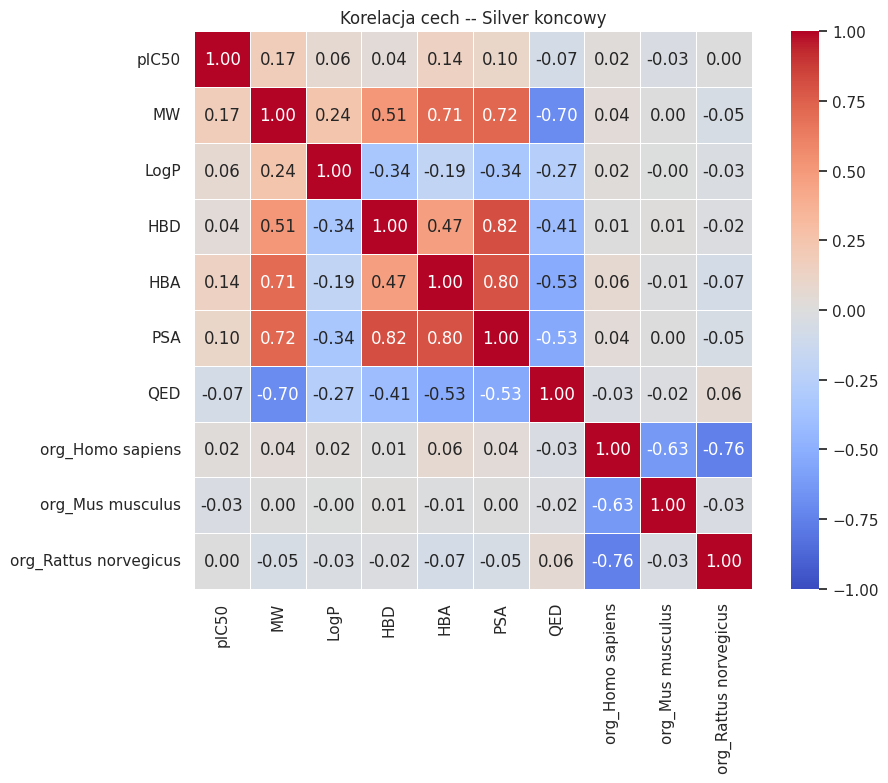


Silnie skorelowane pary (|r| > 0.8):
  PSA <-> HBD: 0.8190
  PSA <-> HBA: 0.8030

Zapisano: chembl_work/parquet_silver_final/silver_final.parquet
GOTOWE! 2,495,755 wierszy x 11 kolumn


In [4]:

# ==============================================================================
# SILVER KONCOWY: JOIN + RDKit (MW, LogP, HBD, HBA, PSA, QED) + One-Hot Organism
# ==============================================================================
import pandas as pd
import numpy as np
import os
import subprocess, importlib

subprocess.check_call(["pip", "install", "-q", "numpy<2"])
importlib.invalidate_caches()

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, QED as QED_module
    print("RDKit OK")
except (ImportError, AttributeError):
    subprocess.check_call(["pip", "install", "-q", "rdkit-pypi"])
    from rdkit import Chem
    from rdkit.Chem import Descriptors, QED as QED_module
    print("RDKit zainstalowany")

SILVER_DIR = os.path.join("chembl_work", "parquet_silver")
FINAL_DIR = os.path.join("chembl_work", "parquet_silver_final")
os.makedirs(FINAL_DIR, exist_ok=True)

# ==============================================================================
# 1. WCZYTANIE SILVER
# ==============================================================================
print("\nWczytywanie Silver...")
df_act = pd.read_parquet(os.path.join(SILVER_DIR, "activities_silver.parquet"))
df_ass = pd.read_parquet(os.path.join(SILVER_DIR, "assays_silver.parquet"))
df_tgt = pd.read_parquet(os.path.join(SILVER_DIR, "targets_silver.parquet"))
df_mol = pd.read_parquet(os.path.join(SILVER_DIR, "molecules_silver.parquet"))

print(f"  Activities: {df_act.shape}")
print(f"  Assays:     {df_ass.shape}")
print(f"  Targets:    {df_tgt.shape}")
print(f"  Molecules:  {df_mol.shape}")

# ==============================================================================
# 2. JOIN: activities -> assays -> targets -> molecules
# ==============================================================================
print("\nJOIN...")
n0 = len(df_act)

df = df_act.merge(df_ass, on='assay_id', how='inner')
print(f"  + assays (assay_id):    {len(df):,} (utrata: {n0 - len(df):,})")

n1 = len(df)
df = df.merge(df_tgt, on='tid', how='left')
n_no_tid = df['organism'].isnull().sum()
df['organism'] = df['organism'].fillna('Homo sapiens')
print(f"  + targets (tid):        {len(df):,} (domyslny organism dla {n_no_tid:,} wierszy)")

n2 = len(df)
df = df.merge(df_mol, on='molregno', how='inner')
print(f"  + molecules (molregno): {len(df):,} (utrata: {n2 - len(df):,})")

print(f"\n  {n0:,} -> {len(df):,} ({len(df)/n0*100:.1f}% zachowane)")

df = df.drop(columns=['activity_id', 'assay_id', 'tid', 'molregno'])
del df_act, df_ass, df_tgt, df_mol
import gc; gc.collect()

# ==============================================================================
# 3. RDKit: MW, LogP, HBD, HBA, PSA, QED
# ==============================================================================
print("\nRDKit deskryptory ze SMILES...")

def compute_descriptors(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return [np.nan] * 6
        return [
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol),
            QED_module.qed(mol),
        ]
    except Exception:
        return [np.nan] * 6

DESC_COLS = ['MW', 'LogP', 'HBD', 'HBA', 'PSA', 'QED']

unique_smi = df[['canonical_smiles']].drop_duplicates().reset_index(drop=True)
print(f"  Obliczanie dla {len(unique_smi):,} unikalnych SMILES...")

results = []
for i, smi in enumerate(unique_smi['canonical_smiles']):
    results.append(compute_descriptors(smi))
    if (i + 1) % 50000 == 0:
        print(f"    {i+1:,}/{len(unique_smi):,}...")

desc_df = pd.DataFrame(results, columns=DESC_COLS)
desc_df['canonical_smiles'] = unique_smi['canonical_smiles'].values

df = df.merge(desc_df, on='canonical_smiles', how='left')

n_failed = df['MW'].isnull().sum()
print(f"  Nieudane SMILES: {n_failed:,} ({n_failed/len(df)*100:.2f}%)")
df = df.dropna(subset=DESC_COLS)
print(f"  Po usunieciu blednych: {len(df):,}")

# ==============================================================================
# 4. ONE-HOT: organism (Homo sapiens / Rattus norvegicus / Mus musculus)
# ==============================================================================
print("\nOne-Hot Encoding organism...")
print(df['organism'].value_counts().to_string())

dummies = pd.get_dummies(df['organism'], prefix='org', dtype=int)
df = pd.concat([df.drop(columns=['organism']), dummies], axis=1)
print(f"  +{dummies.shape[1]} kolumn one-hot")

# ==============================================================================
# 5. OUTLIER REMOVAL (percentyl 0.1% / 99.9%)
# ==============================================================================
print("\nUsuwanie skrajnych outlierow (percentyl 0.1% -- 99.9%)...")
n_before_outlier = len(df)
NUM_FEATURES = ['pIC50'] + DESC_COLS

for col in NUM_FEATURES:
    lo = df[col].quantile(0.001)
    hi = df[col].quantile(0.999)
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    df = df[(df[col] >= lo) & (df[col] <= hi)]
    if n_out > 0:
        print(f"  {col:<10} usunieto {n_out:,} outlierow  (zakres: [{lo:.2f}, {hi:.2f}])")

n_removed = n_before_outlier - len(df)
print(f"  {n_before_outlier:,} -> {len(df):,} (usunieto {n_removed:,} / {n_removed/n_before_outlier*100:.2f}%)")

# ==============================================================================
# 6. NORMALIZACJA (StandardScaler na cechach numerycznych)
# ==============================================================================
print("\nNormalizacja cech (StandardScaler)...")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[NUM_FEATURES] = scaler.fit_transform(df[NUM_FEATURES])

print("  Parametry skalera (mean / std):")
for col, m, s in zip(NUM_FEATURES, scaler.mean_, scaler.scale_):
    print(f"    {col:<10} u={m:.4f}  s={s:.4f}")
print("  Cechy znormalizowane (mean~0, std~1)")

# ==============================================================================
# 7. FINALNA TABELA
# ==============================================================================
feature_cols = ['pIC50'] + DESC_COLS + ['canonical_smiles'] + sorted([c for c in df.columns if c.startswith('org_')])
df = df[feature_cols]

print("\n" + "=" * 70)
print("FINALNA TABELA SILVER (KONCOWA)")
print("=" * 70)
print(f"Wymiary: {df.shape[0]:,} wierszy x {df.shape[1]} kolumn\n")

print(f"{'#':<4} {'Kolumna':<30} {'Typ':<12} {'Nulle':<8} {'Min':>10} {'Max':>10}")
print("-" * 78)
for i, col in enumerate(df.columns, 1):
    n_null = df[col].isnull().sum()
    if df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        lo, hi = f"{df[col].min():.2f}", f"{df[col].max():.2f}"
    else:
        lo, hi = "-", "-"
    print(f"{i:<4} {col:<30} {str(df[col].dtype):<12} {n_null:<8} {lo:>10} {hi:>10}")

total_nulls = df.isnull().sum().sum()
print(f"\n{'ZERO nulli -- dataset kompletny!' if total_nulls == 0 else f'UWAGA: {total_nulls:,} nulli'}")

print("\nProbka (Top 5):")
display(df.head())

print("\nStatystyki:")
display(df.describe())

# ==============================================================================
# 8. SPRAWDZENIE PUSTYCH WARTOSCI I KORELACJA
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("WALIDACJA KONCOWA")
print("=" * 70)

print("\nSprawdzenie pustych wartosci per kolumna:")
null_check = df.isnull().sum()
for col_name, n_null in null_check.items():
    pct = n_null / len(df) * 100
    status = "OK" if n_null == 0 else f"{n_null:,} ({pct:.2f}%)"
    print(f"  {col_name:<30} {status}")

total_nulls_final = null_check.sum()
print(f"\n  Laczna liczba pustych: {total_nulls_final:,}")

num_cols_corr = [c for c in df.columns if df[c].dtype in ['float64', 'float32', 'int64', 'int32']]

if len(num_cols_corr) > 1:
    print("\nMacierz korelacji cech numerycznych:")
    corr = df[num_cols_corr].corr()
    display(corr.round(3))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
                square=True, linewidths=0.5)
    plt.title("Korelacja cech -- Silver koncowy")
    plt.tight_layout()
    plt.show()

    print("\nSilnie skorelowane pary (|r| > 0.8):")
    found = False
    for i in range(len(corr.columns)):
        for j in range(i):
            r = corr.iloc[i, j]
            if abs(r) > 0.8:
                print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {r:.4f}")
                found = True
    if not found:
        print("  Brak silnie skorelowanych par (|r| > 0.8)")

# ZAPIS
final_path = os.path.join(FINAL_DIR, "silver_final.parquet")
df.to_parquet(final_path, index=False)
print(f"\nZapisano: {final_path}")
print(f"GOTOWE! {df.shape[0]:,} wierszy x {df.shape[1]} kolumn")


In [5]:
# Zapis do gcs
import subprocess
import os

BUCKET_ID = "project-0c281f60-a9e8-4b55-949-chembl-data"
BUCKET_ROOT = f"gs://{BUCKET_ID}"

LOCAL_WORK_DIR = "chembl_work"
LOCAL_SILVER = os.path.join(LOCAL_WORK_DIR, "parquet_silver")

GCS_SILVER = f"{BUCKET_ROOT}/silver"

print(f"zapis do gcs ({GCS_SILVER})...")

command = ["gsutil", "-m", "cp", "-r", f"{LOCAL_SILVER}/*.parquet", GCS_SILVER]
subprocess.check_call(command)

zapis do gcs (gs://project-0c281f60-a9e8-4b55-949-chembl-data/silver)...


Copying file://chembl_work/parquet_silver/activities_silver.parquet [Content-Type=application/octet-stream]...
Copying file://chembl_work/parquet_silver/molecules_silver.parquet [Content-Type=application/octet-stream]...
Copying file://chembl_work/parquet_silver/assays_silver.parquet [Content-Type=application/octet-stream]...
Copying file://chembl_work/parquet_silver/targets_silver.parquet [Content-Type=application/octet-stream]...
\ [4/4 files][119.0 MiB/119.0 MiB] 100% Done                                    
Operation completed over 4 objects/119.0 MiB.                                    


0